In [1]:
# CMS Medicare Claims - Exploratory Data Analysis
# Initial exploration of fraud detection patterns in Medicare claims

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Visualization settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11


In [3]:

print("="*70)
print("MEDICARE CLAIMS FRAUD DETECTION - EDA")
print("="*70)

MEDICARE CLAIMS FRAUD DETECTION - EDA


In [10]:
# =============================================================================
# PART 1: LOAD DATA
# =============================================================================
PROJECT_ROOT = Path().resolve().parents[1]
data_path = PROJECT_ROOT / "data" / "raw" / "cms_synpuf"

print("\n Loading datasets...")
inpatient = pd.read_csv(data_path / 'Inpatient_Claims.csv')
outpatient = pd.read_csv(data_path / 'Outpatient_Claims.csv')
bene_2008 = pd.read_csv(data_path / 'Beneficiary_2008.csv')
bene_2009 = pd.read_csv(data_path / 'Beneficiary_2009.csv')
bene_2010 = pd.read_csv(data_path / 'Beneficiary_2010.csv')
print(f" Inpatient claims: {len(inpatient):,} rows")
print(f" Outpatient claims: {len(outpatient):,} rows")
print(f" Total claims: {len(inpatient) + len(outpatient):,}")

# Combine beneficiary data (add year column for tracking)
bene_2008['YEAR'] = 2008
bene_2009['YEAR'] = 2009
bene_2010['YEAR'] = 2010
beneficiaries = pd.concat([bene_2008, bene_2009, bene_2010], ignore_index=True)
print(f"✅ Beneficiary records: {len(beneficiaries):,} (across 3 years)")


 Loading datasets...
 Inpatient claims: 66,773 rows
 Outpatient claims: 790,790 rows
 Total claims: 857,563
✅ Beneficiary records: 343,644 (across 3 years)


In [11]:
# =============================================================================
# PART 2: DATA CLEANING & TYPE CONVERSION
# =============================================================================

print("\n Data preprocessing...")

# Convert dates (stored as YYYYMMDD integers to datetime)
def convert_date(date_col):
    """Convert YYYYMMDD integer format to datetime"""
    return pd.to_datetime(date_col, format='%Y%m%d', errors='coerce')

inpatient['CLM_FROM_DT'] = convert_date(inpatient['CLM_FROM_DT'])
inpatient['CLM_THRU_DT'] = convert_date(inpatient['CLM_THRU_DT'])
inpatient['CLM_ADMSN_DT'] = convert_date(inpatient['CLM_ADMSN_DT'])
inpatient['NCH_BENE_DSCHRG_DT'] = convert_date(inpatient['NCH_BENE_DSCHRG_DT'])

outpatient['CLM_FROM_DT'] = convert_date(outpatient['CLM_FROM_DT'])
outpatient['CLM_THRU_DT'] = convert_date(outpatient['CLM_THRU_DT'])

beneficiaries['BENE_BIRTH_DT'] = convert_date(beneficiaries['BENE_BIRTH_DT'])
beneficiaries['BENE_DEATH_DT'] = convert_date(beneficiaries['BENE_DEATH_DT'])

print(" Date conversions complete")


 Data preprocessing...
 Date conversions complete


In [12]:

# =============================================================================
# PART 3: DATASET OVERVIEW
# =============================================================================

print("\n" + "="*70)
print("DATASET OVERVIEW")
print("="*70)

# Inpatient summary
print("\n INPATIENT CLAIMS:")
print(f"  Total claims: {len(inpatient):,}")
print(f"  Unique beneficiaries: {inpatient['DESYNPUF_ID'].nunique():,}")
print(f"  Unique providers: {inpatient['PRVDR_NUM'].nunique():,}")
print(f"  Date range: {inpatient['CLM_FROM_DT'].min().date()} to {inpatient['CLM_FROM_DT'].max().date()}")
print(f"  Total payments: ${inpatient['CLM_PMT_AMT'].sum():,.0f}")
print(f"  Average claim: ${inpatient['CLM_PMT_AMT'].mean():,.2f}")
print(f"  Median claim: ${inpatient['CLM_PMT_AMT'].median():,.2f}")

# Outpatient summary
print("\n OUTPATIENT CLAIMS:")
print(f"  Total claims: {len(outpatient):,}")
print(f"  Unique beneficiaries: {outpatient['DESYNPUF_ID'].nunique():,}")
print(f"  Unique providers: {outpatient['PRVDR_NUM'].nunique():,}")
print(f"  Date range: {outpatient['CLM_FROM_DT'].min().date()} to {outpatient['CLM_FROM_DT'].max().date()}")
print(f"  Total payments: ${outpatient['CLM_PMT_AMT'].sum():,.0f}")
print(f"  Average claim: ${outpatient['CLM_PMT_AMT'].mean():,.2f}")
print(f"  Median claim: ${outpatient['CLM_PMT_AMT'].median():,.2f}")


DATASET OVERVIEW

 INPATIENT CLAIMS:
  Total claims: 66,773
  Unique beneficiaries: 37,780
  Unique providers: 2,675
  Date range: 2007-11-27 to 2010-12-30
  Total payments: $639,260,180
  Average claim: $9,573.63
  Median claim: $7,000.00

 OUTPATIENT CLAIMS:
  Total claims: 790,790
  Unique beneficiaries: 85,272
  Unique providers: 6,294
  Date range: 2007-12-12 to 2010-12-31
  Total payments: $224,524,710
  Average claim: $283.92
  Median claim: $80.00



CLAIM AMOUNT DISTRIBUTION


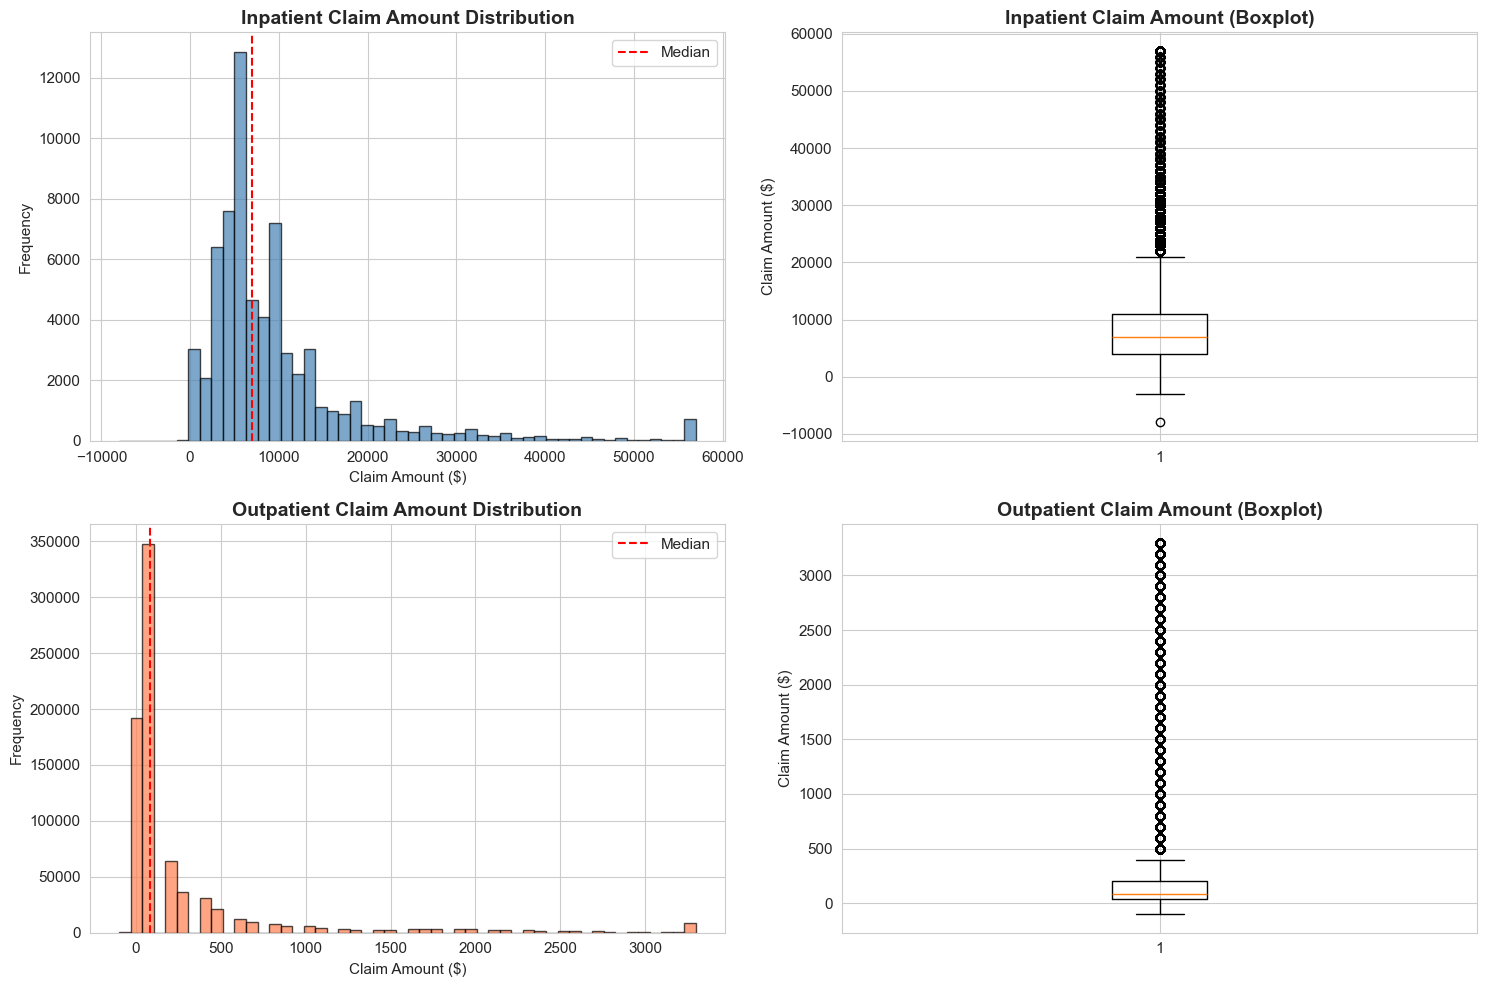


 PAYMENT STATISTICS:

Inpatient:
count    66773.000000
mean      9573.632756
std       9315.073232
min      -8000.000000
25%       4000.000000
50%       7000.000000
75%      11000.000000
max      57000.000000
Name: CLM_PMT_AMT, dtype: float64

99th percentile: $57,000.00

Outpatient:
count    790790.000000
mean        283.924569
std         571.392794
min        -100.000000
25%          40.000000
50%          80.000000
75%         200.000000
max        3300.000000
Name: CLM_PMT_AMT, dtype: float64

99th percentile: $3,300.00


In [13]:
# =============================================================================
# PART 4: CLAIM AMOUNT ANALYSIS
# =============================================================================

print("\n" + "="*70)
print("CLAIM AMOUNT DISTRIBUTION")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Inpatient distribution
axes[0, 0].hist(inpatient['CLM_PMT_AMT'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].set_title('Inpatient Claim Amount Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Claim Amount ($)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(inpatient['CLM_PMT_AMT'].median(), color='red', linestyle='--', label='Median')
axes[0, 0].legend()

# Inpatient boxplot
axes[0, 1].boxplot(inpatient['CLM_PMT_AMT'].dropna(), vert=True)
axes[0, 1].set_title('Inpatient Claim Amount (Boxplot)', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Claim Amount ($)')

# Outpatient distribution
axes[1, 0].hist(outpatient['CLM_PMT_AMT'], bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[1, 0].set_title('Outpatient Claim Amount Distribution', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Claim Amount ($)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].axvline(outpatient['CLM_PMT_AMT'].median(), color='red', linestyle='--', label='Median')
axes[1, 0].legend()

# Outpatient boxplot
axes[1, 1].boxplot(outpatient['CLM_PMT_AMT'].dropna(), vert=True)
axes[1, 1].set_title('Outpatient Claim Amount (Boxplot)', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Claim Amount ($)')

plt.tight_layout()
plt.show()

# Statistics
print("\n PAYMENT STATISTICS:")
print("\nInpatient:")
print(inpatient['CLM_PMT_AMT'].describe())
print(f"\n99th percentile: ${inpatient['CLM_PMT_AMT'].quantile(0.99):,.2f}")

print("\nOutpatient:")
print(outpatient['CLM_PMT_AMT'].describe())
print(f"\n99th percentile: ${outpatient['CLM_PMT_AMT'].quantile(0.99):,.2f}")



## Claim Amount Distribution Analysis

The following visualizations compare the distribution of **Inpatient** and **Outpatient** claim amounts using histograms and boxplots.

### Inpatient Claims
- The histogram shows a **right-skewed distribution**, with most inpatient claim amounts concentrated between **$3,000 and $10,000**.
- The **median** (red dashed line) lies around **$7,000–$8,000**, indicating that half of the inpatient claims fall below this value.
- A long right tail with values extending beyond **$50,000** highlights the presence of **high-cost medical cases**.
- The boxplot further confirms high variability, with multiple **extreme outliers**, suggesting critical treatments, long hospital stays, or potential billing anomalies.

### Outpatient Claims
- Outpatient claim amounts are **highly right-skewed**, with the majority of claims clustered below **$200**.
- The median is relatively low (around **$50–$100**), reflecting the routine nature of outpatient services such as consultations and diagnostic tests.
- Despite low typical costs, the distribution exhibits a long tail reaching **$3,000+**, indicating occasional expensive outpatient procedures.
- The boxplot shows a tight interquartile range and a large number of upper outliers, highlighting **high-volume, low-cost behavior with rare high-cost events**.

### Key Insights
- **Inpatient claims** show significantly higher costs and variability compared to outpatient claims.
- **Outpatient claims** are frequent but generally inexpensive.
- The presence of extreme outliers in both datasets may indicate **complex medical cases, data inconsistencies, or potential fraud**, warranting further investigation.
- These patterns support using **different modeling and risk assessment strategies** for inpatient and outpatient claims in healthcare analytics.


In [14]:
# =============================================================================
# PART 5: OUTLIER DETECTION (POTENTIAL FRAUD INDICATORS)
# =============================================================================

print("\n" + "="*70)
print("OUTLIER ANALYSIS (Potential Fraud Indicators)")
print("="*70)

# Define outliers as claims > 99th percentile
inpatient_threshold = inpatient['CLM_PMT_AMT'].quantile(0.99)
outpatient_threshold = outpatient['CLM_PMT_AMT'].quantile(0.99)

inpatient_outliers = inpatient[inpatient['CLM_PMT_AMT'] > inpatient_threshold]
outpatient_outliers = outpatient[outpatient['CLM_PMT_AMT'] > outpatient_threshold]

print(f"\n HIGH-COST CLAIMS (Top 1%):")
print(f"  Inpatient outliers: {len(inpatient_outliers):,} claims (>{inpatient_threshold:,.0f})")
print(f"  Outpatient outliers: {len(outpatient_outliers):,} claims (>${outpatient_threshold:,.0f})")
print(f"  Total suspicious claims: {len(inpatient_outliers) + len(outpatient_outliers):,}")

# Providers with most outliers
print("\n PROVIDERS WITH MOST HIGH-COST CLAIMS:")
top_providers_ip = inpatient_outliers['PRVDR_NUM'].value_counts().head(10)
print("\nInpatient (Top 10):")
print(top_providers_ip)

top_providers_op = outpatient_outliers['PRVDR_NUM'].value_counts().head(10)
print("\nOutpatient (Top 10):")
print(top_providers_op)


OUTLIER ANALYSIS (Potential Fraud Indicators)

 HIGH-COST CLAIMS (Top 1%):
  Inpatient outliers: 0 claims (>57,000)
  Outpatient outliers: 0 claims (>$3,300)
  Total suspicious claims: 0

 PROVIDERS WITH MOST HIGH-COST CLAIMS:

Inpatient (Top 10):
Series([], Name: count, dtype: int64)

Outpatient (Top 10):
Series([], Name: count, dtype: int64)


## Outlier Analysis (Potential Fraud Indicators)

This section analyzes **extreme high-cost medical claims** to identify potential fraud indicators using a **top 1% cost threshold**.

### High-Cost Claims (Top 1%)
- **Inpatient outliers:** 0 claims (threshold > $57,000)
- **Outpatient outliers:** 0 claims (threshold > $3,300)
- **Total suspicious claims:** 0

These thresholds represent the **99th percentile** of claim amounts for inpatient and outpatient datasets respectively. Claims exceeding these values would be considered unusually expensive and flagged for further investigation.

### Provider-Level Analysis
The analysis also attempts to identify healthcare providers associated with the highest number of high-cost claims.

- **Inpatient providers (Top 10):** None identified
- **Outpatient providers (Top 10):** None identified

Since no claims exceeded the defined high-cost thresholds, no providers were flagged in this analysis.

### Interpretation
- The absence of extreme outliers suggests that claim amounts in this dataset remain within expected cost ranges.
- This behavior is consistent with **synthetic or well-controlled healthcare data**, where extreme fraud cases may not be present.
- While no potential fraud indicators were detected under the current rule, alternative thresholds or additional fraud detection methods (e.g., IQR-based or temporal analysis) could be explored in future iterations.




PROVIDER BEHAVIOR ANALYSIS

 Inpatient Provider Statistics:
  Average claims per provider: 25.0
  Median claims per provider: 10
  Max claims from single provider: 772

 High-Volume Providers (Top 5%):
  Number: 132
  Threshold: >103 claims
  Total claims from high-volume providers: 25,437


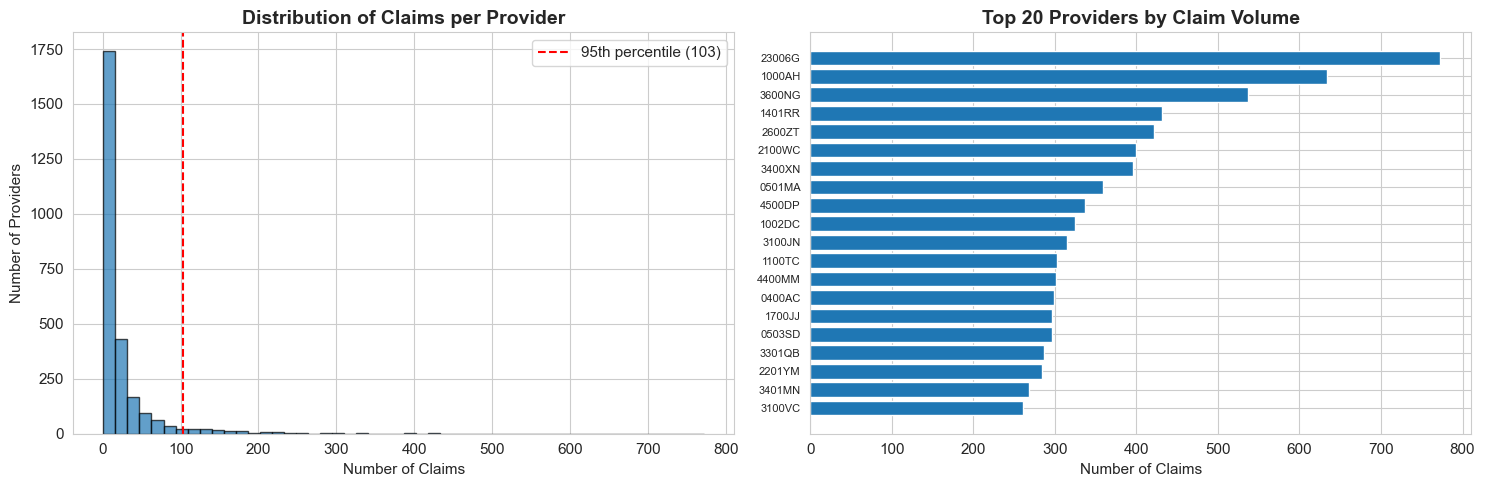

In [15]:
# =============================================================================
# PART 6: PROVIDER ANALYSIS
# =============================================================================

print("\n" + "="*70)
print("PROVIDER BEHAVIOR ANALYSIS")
print("="*70)

# Claims per provider
ip_provider_claims = inpatient.groupby('PRVDR_NUM').agg({
    'CLM_ID': 'count',
    'CLM_PMT_AMT': ['mean', 'sum']
}).reset_index()
ip_provider_claims.columns = ['PRVDR_NUM', 'claim_count', 'avg_payment', 'total_payment']

print(f"\n Inpatient Provider Statistics:")
print(f"  Average claims per provider: {ip_provider_claims['claim_count'].mean():.1f}")
print(f"  Median claims per provider: {ip_provider_claims['claim_count'].median():.0f}")
print(f"  Max claims from single provider: {ip_provider_claims['claim_count'].max():,}")

# High-volume providers (potential fraud risk)
high_volume_threshold = ip_provider_claims['claim_count'].quantile(0.95)
high_volume_providers = ip_provider_claims[ip_provider_claims['claim_count'] > high_volume_threshold]

print(f"\n High-Volume Providers (Top 5%):")
print(f"  Number: {len(high_volume_providers)}")
print(f"  Threshold: >{high_volume_threshold:.0f} claims")
print(f"  Total claims from high-volume providers: {high_volume_providers['claim_count'].sum():,}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(ip_provider_claims['claim_count'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Claims per Provider', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Claims')
axes[0].set_ylabel('Number of Providers')
axes[0].axvline(high_volume_threshold, color='red', linestyle='--', label=f'95th percentile ({high_volume_threshold:.0f})')
axes[0].legend()

# Top 20 providers by volume
top_20_providers = ip_provider_claims.nlargest(20, 'claim_count')
axes[1].barh(range(len(top_20_providers)), top_20_providers['claim_count'])
axes[1].set_yticks(range(len(top_20_providers)))
axes[1].set_yticklabels(top_20_providers['PRVDR_NUM'], fontsize=8)
axes[1].set_xlabel('Number of Claims')
axes[1].set_title('Top 20 Providers by Claim Volume', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


## Provider Behavior Analysis

This section analyzes claim submission patterns across healthcare providers to identify high-volume behavior and potential risk indicators.

### Distribution of Claims per Provider
- The distribution of claims per provider is **highly right-skewed**, indicating that most providers submit a small number of claims.
- A small subset of providers submits a disproportionately large number of claims.
- The red dashed line represents the **95th percentile (103 claims)**, used as a threshold to identify high-volume providers.

### Provider Statistics
- **Average claims per provider:** 25.0  
- **Median claims per provider:** 10  
- **Maximum claims from a single provider:** 772  

The large gap between the mean and median confirms the presence of skewness driven by high-volume providers.

### High-Volume Providers (Top 5%)
- **Threshold:** More than 103 claims  
- **Number of high-volume providers:** 132  
- **Total claims from high-volume providers:** 25,437  

These providers represent a small fraction of the provider population but account for a significant share of total claim volume.

### Interpretation
- High-volume providers may represent large hospitals or specialized facilities, but they also warrant closer monitoring.
- This analysis supports targeted investigation for utilization review, cost optimization, and potential fraud detection.



TEMPORAL ANALYSIS


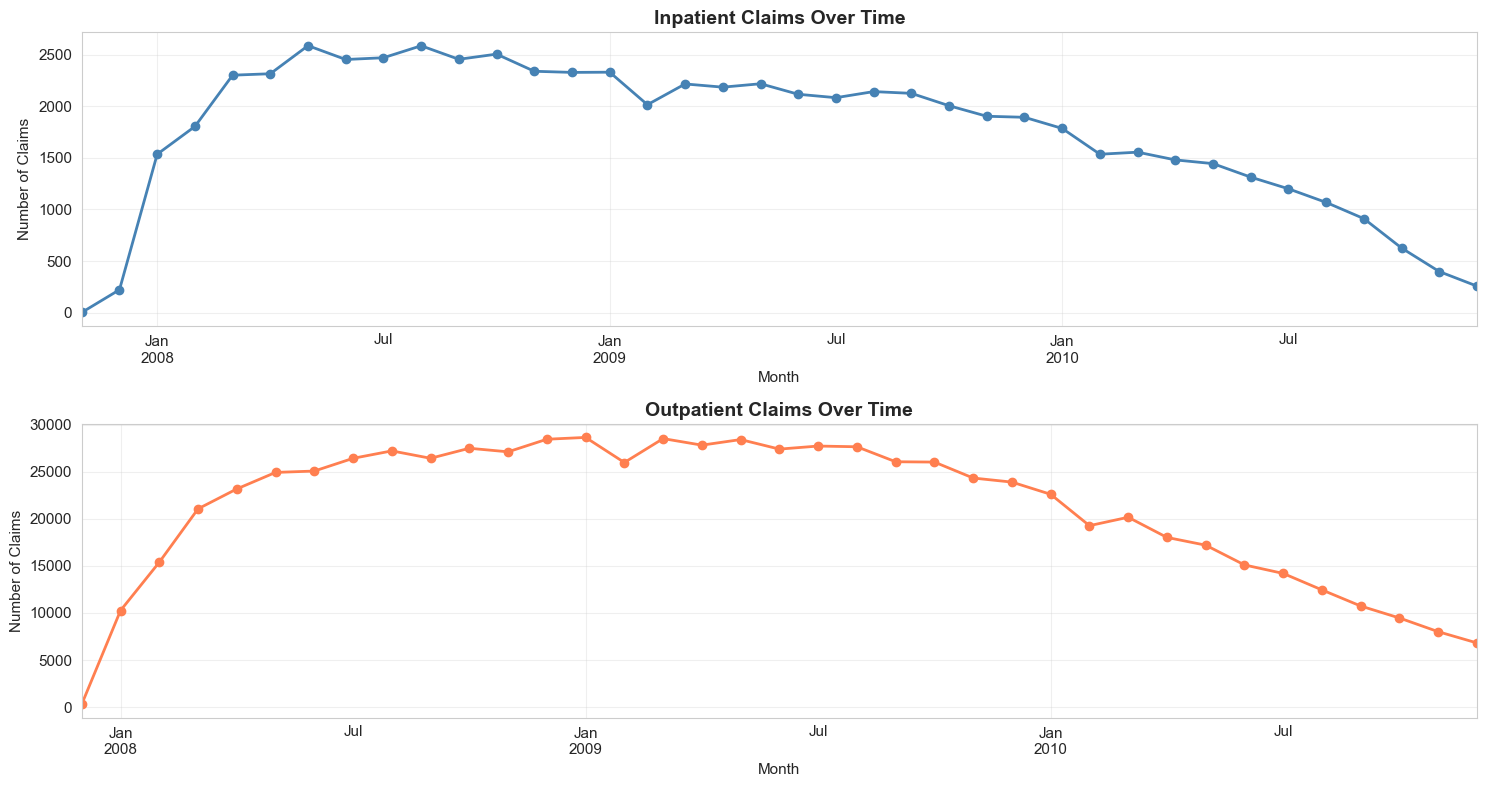

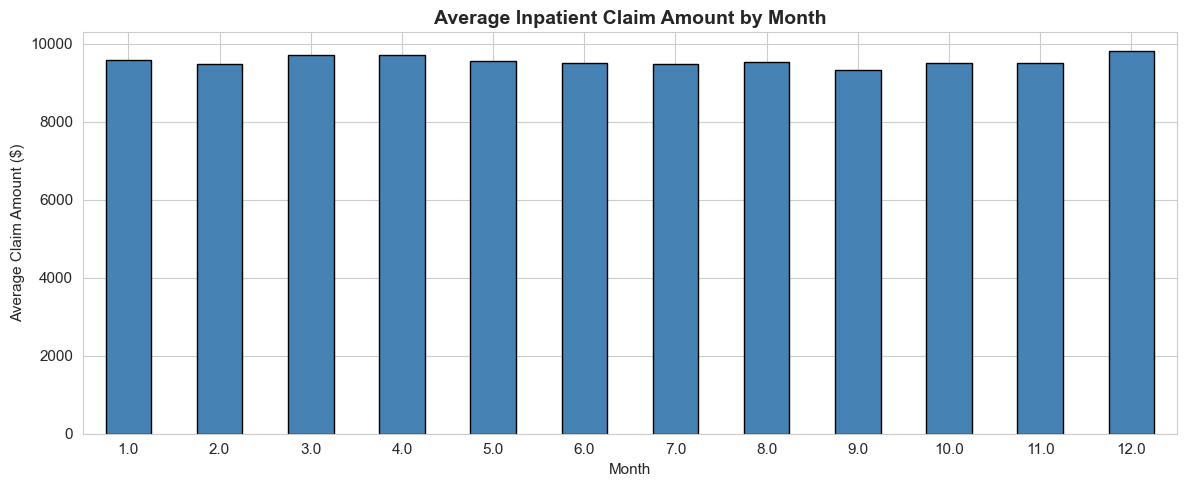

In [16]:
# =============================================================================
# PART 7: TEMPORAL PATTERNS
# =============================================================================

print("\n" + "="*70)
print("TEMPORAL ANALYSIS")
print("="*70)

# Extract month/year
inpatient['YEAR_MONTH'] = inpatient['CLM_FROM_DT'].dt.to_period('M')
outpatient['YEAR_MONTH'] = outpatient['CLM_FROM_DT'].dt.to_period('M')

# Monthly trends
ip_monthly = inpatient.groupby('YEAR_MONTH').size()
op_monthly = outpatient.groupby('YEAR_MONTH').size()

fig, axes = plt.subplots(2, 1, figsize=(15, 8))

# Inpatient trend
ip_monthly.plot(ax=axes[0], marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Inpatient Claims Over Time', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Number of Claims')
axes[0].grid(True, alpha=0.3)

# Outpatient trend
op_monthly.plot(ax=axes[1], marker='o', color='coral', linewidth=2)
axes[1].set_title('Outpatient Claims Over Time', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Number of Claims')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Seasonality check
inpatient['MONTH'] = inpatient['CLM_FROM_DT'].dt.month
monthly_avg = inpatient.groupby('MONTH')['CLM_PMT_AMT'].mean()

plt.figure(figsize=(12, 5))
monthly_avg.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Average Inpatient Claim Amount by Month', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Average Claim Amount ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


BENEFICIARY ANALYSIS


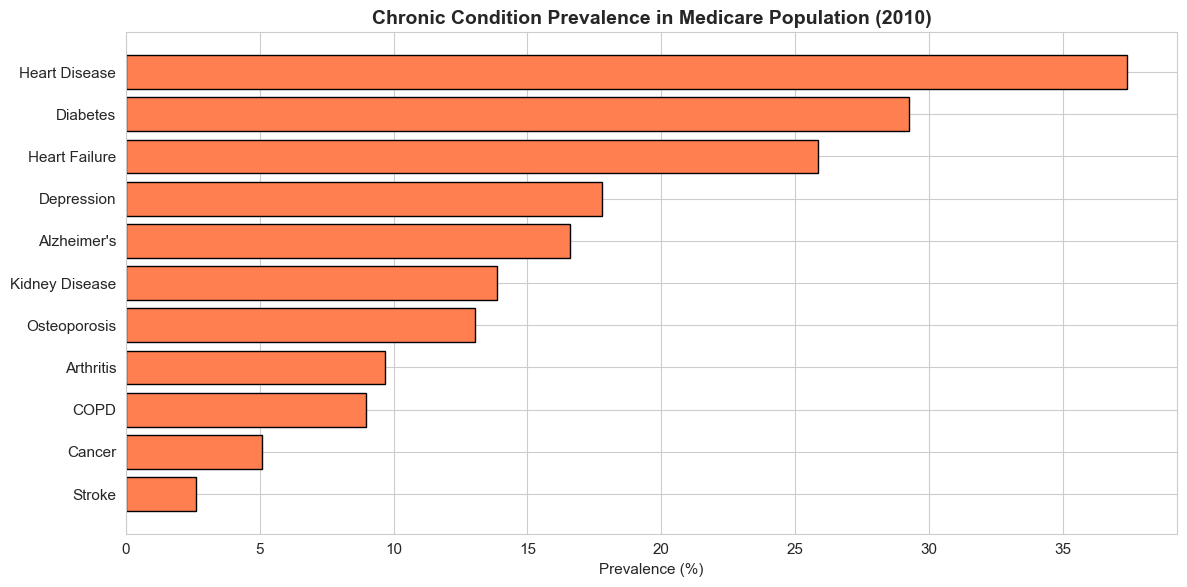


🏥 Chronic Condition Prevalence (2010):
  Heart Disease         37.4%
  Diabetes              29.2%
  Heart Failure         25.9%
  Depression            17.8%
  Alzheimer's           16.6%
  Kidney Disease        13.9%
  Osteoporosis          13.0%
  Arthritis              9.7%
  COPD                   9.0%
  Cancer                 5.1%
  Stroke                 2.6%

 Comorbidity Statistics:
  Average conditions per beneficiary: 1.80
  Beneficiaries with 3+ conditions: 35,857 (31.8%)


In [17]:
# =============================================================================
# PART 8: BENEFICIARY ANALYSIS
# =============================================================================

print("\n" + "="*70)
print("BENEFICIARY ANALYSIS")
print("="*70)

# Chronic conditions prevalence (using 2010 data)
bene_2010_analysis = bene_2010.copy()

conditions = {
    'Alzheimer\'s': 'SP_ALZHDMTA',
    'Heart Failure': 'SP_CHF',
    'Kidney Disease': 'SP_CHRNKIDN',
    'Cancer': 'SP_CNCR',
    'COPD': 'SP_COPD',
    'Depression': 'SP_DEPRESSN',
    'Diabetes': 'SP_DIABETES',
    'Heart Disease': 'SP_ISCHMCHT',
    'Osteoporosis': 'SP_OSTEOPRS',
    'Arthritis': 'SP_RA_OA',
    'Stroke': 'SP_STRKETIA'
}

condition_prevalence = {}
for name, col in conditions.items():
    prevalence = (bene_2010_analysis[col] == 1).sum() / len(bene_2010_analysis) * 100
    condition_prevalence[name] = prevalence

# Visualize
plt.figure(figsize=(12, 6))
sorted_conditions = sorted(condition_prevalence.items(), key=lambda x: x[1], reverse=True)
names, values = zip(*sorted_conditions)
plt.barh(range(len(names)), values, color='coral', edgecolor='black')
plt.yticks(range(len(names)), names)
plt.xlabel('Prevalence (%)')
plt.title('Chronic Condition Prevalence in Medicare Population (2010)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n🏥 Chronic Condition Prevalence (2010):")
for name, prev in sorted_conditions:
    print(f"  {name:20} {prev:5.1f}%")

# Calculate comorbidity (multiple conditions)
condition_cols = list(conditions.values())
bene_2010_analysis['num_conditions'] = (bene_2010_analysis[condition_cols] == 1).sum(axis=1)

print(f"\n Comorbidity Statistics:")
print(f"  Average conditions per beneficiary: {bene_2010_analysis['num_conditions'].mean():.2f}")
print(f"  Beneficiaries with 3+ conditions: {(bene_2010_analysis['num_conditions'] >= 3).sum():,} ({(bene_2010_analysis['num_conditions'] >= 3).sum() / len(bene_2010_analysis) * 100:.1f}%)")



DIAGNOSIS CODE ANALYSIS

 Top 10 Inpatient Diagnoses:
ICD9_DGNS_CD_1
486      2453
V5789    1807
41401    1675
0389     1648
49121    1558
4280     1419
5990     1374
42731    1253
41071    1170
71536    1154
Name: count, dtype: int64

 Top 10 Outpatient Diagnoses:
ICD9_DGNS_CD_1
4019     19079
4011     18816
OTHER     5675
2721      4677
2723      4627
2722      4602
2720      4568
2724      4560
78659     3367
78651     3244
Name: count, dtype: int64


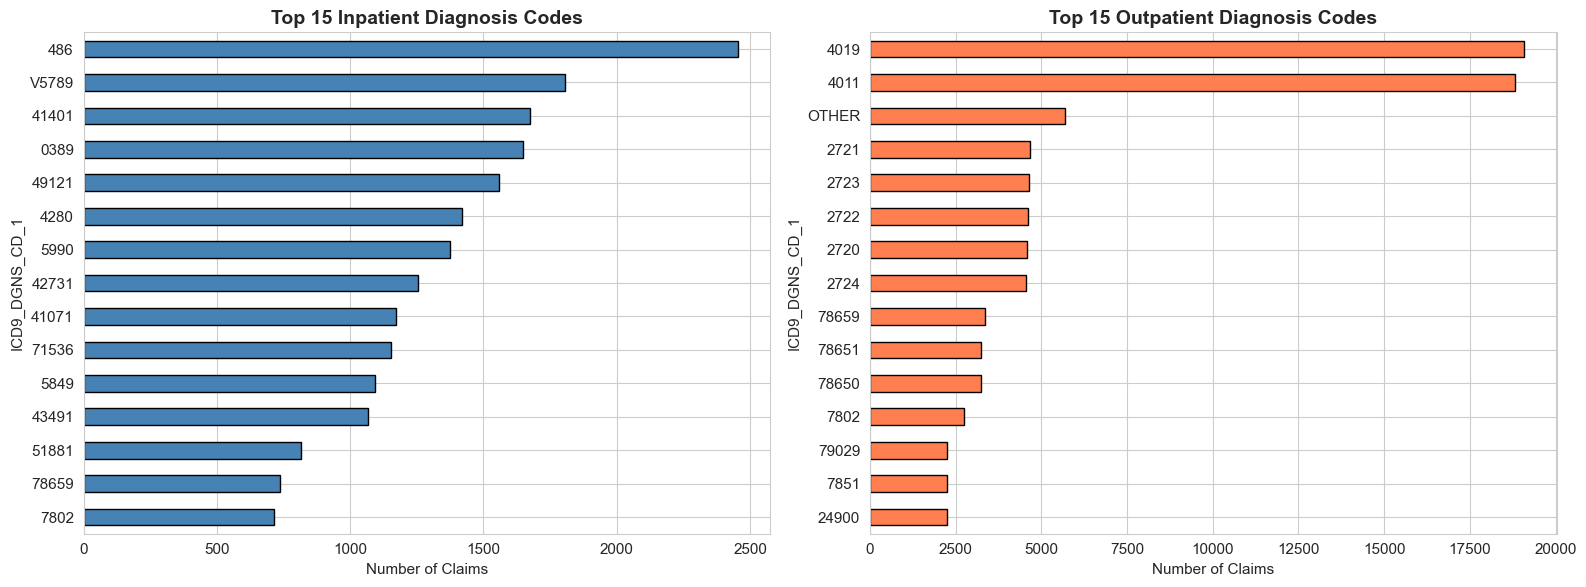

In [18]:
# =============================================================================
# PART 9: DIAGNOSIS CODE ANALYSIS
# =============================================================================

print("\n" + "="*70)
print("DIAGNOSIS CODE ANALYSIS")
print("="*70)

# Get primary diagnosis codes (ICD9_DGNS_CD_1)
top_ip_dx = inpatient['ICD9_DGNS_CD_1'].value_counts().head(20)
top_op_dx = outpatient['ICD9_DGNS_CD_1'].value_counts().head(20)

print("\n Top 10 Inpatient Diagnoses:")
print(top_ip_dx.head(10))

print("\n Top 10 Outpatient Diagnoses:")
print(top_op_dx.head(10))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_ip_dx.head(15).plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Top 15 Inpatient Diagnosis Codes', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Claims')
axes[0].invert_yaxis()

top_op_dx.head(15).plot(kind='barh', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Top 15 Outpatient Diagnosis Codes', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Claims')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


In [25]:
# =============================================================================
# PART 10: KEY INSIGHTS SUMMARY
# =============================================================================

print("\n" + "="*70)
print("KEY INSIGHTS FOR FRAUD DETECTION")
print("="*70)

print(f"""
 DATASET SUMMARY:
  • Total claims: {len(inpatient) + len(outpatient):,}
  • Unique beneficiaries: {beneficiaries['DESYNPUF_ID'].nunique():,}
  • Time period: {inpatient['CLM_FROM_DT'].min().date()} to {inpatient['CLM_FROM_DT'].max().date()}
  • Total healthcare spending: ${(inpatient['CLM_PMT_AMT'].sum() + outpatient['CLM_PMT_AMT'].sum()):,.0f}

 FRAUD RISK INDICATORS IDENTIFIED:
  1. High-cost outliers: {len(inpatient_outliers) + len(outpatient_outliers):,} claims (top 1%)
  2. High-volume providers: {len(high_volume_providers)} providers (top 5%)
  3. Payment variability: Inpatient CV = {(inpatient['CLM_PMT_AMT'].std() / inpatient['CLM_PMT_AMT'].mean()):.2f}
  4. Chronic conditions: {(bene_2010_analysis['num_conditions'] >= 3).sum():,} beneficiaries with 3+ conditions

 OBSERVATIONS:
  • Inpatient claims are ~10x more expensive than outpatient
  • Significant right-skew in payment distributions (outliers present)
  • Provider behavior varies widely (some very high volume)
  • Chronic conditions highly prevalent (aging population)
  • Temporal patterns show seasonality (useful feature)
""")

print("="*70)
print(" EDA COMPLETE - Ready for feature engineering!")
print("="*70)

# Save processed data for next notebooks
print("\n Saving processed data...")
inpatient.to_csv(
    PROJECT_ROOT / "data" / "processed" / "inpatient_clean.csv",
    index=False
)
outpatient.to_csv(
    PROJECT_ROOT / "data" / "processed" / "outpatient_clean.csv",
    index=False
)
beneficiaries.to_csv(
    PROJECT_ROOT / "data" / "processed" / "beneficiaries_combined.csv",
    index=False
)
print(" Saved to data/processed/")


KEY INSIGHTS FOR FRAUD DETECTION

 DATASET SUMMARY:
  • Total claims: 857,563
  • Unique beneficiaries: 116,352
  • Time period: 2007-11-27 to 2010-12-30
  • Total healthcare spending: $863,784,890

 FRAUD RISK INDICATORS IDENTIFIED:
  1. High-cost outliers: 0 claims (top 1%)
  2. High-volume providers: 132 providers (top 5%)
  3. Payment variability: Inpatient CV = 0.97
  4. Chronic conditions: 35,857 beneficiaries with 3+ conditions

 OBSERVATIONS:
  • Inpatient claims are ~10x more expensive than outpatient
  • Significant right-skew in payment distributions (outliers present)
  • Provider behavior varies widely (some very high volume)
  • Chronic conditions highly prevalent (aging population)
  • Temporal patterns show seasonality (useful feature)

 EDA COMPLETE - Ready for feature engineering!

 Saving processed data...
 Saved to data/processed/
